# Réseau de neurones auto-encodeur


In [1]:
#@title Importations
import numpy as np
import pandas as pd
import plotly.express as px

from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import root_mean_squared_error, confusion_matrix, accuracy_score

from sklearn.model_selection import train_test_split

import pickle

## Apprentissage non-supervisé

Jusqu'ici, on a uniquement utilisé des algorithmes d'**apprentissage supervisé**. On avait des exemples de données pour lesquels on avait les bonnes réponses.

Il existe cependant des techniques qui permettent d'apprendre des choses, même quand on ne connaît pas tout à fait ce qu'on cherche. On parle d'algorithmes **non-supervisés**.

Les grandes catégories d'apprentissage non-supervisé incluent :

- Apprendre la structure de nos données (ex.: découvrir comment les données se regroupent naturellement en catégories)
- Réduire la dimensionalité de nos données (ex.: essayer de résumer 5000 caractéristiques en seulement 15 valeurs, ou encore essayer de trouver une transformation 2D qui permet de regarder des données en plusieurs dimensions).

&nbsp;

On va s'intéresser à une technique de **réduction de dimensionnalité**.

## Réduction de dimensionnalité

On va travailler avec les dessins de visages :

--2026-05-05 14:00:33--  https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/cartoonset10k.pkl.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 43846162 (42M) [application/octet-stream]
Saving to: ‘cartoonset10k.pkl.gz’

cartoonset10k.pkl.g 100%[===================>]  41.81M  --.-KB/s    in 0.1s    

2026-05-05 14:00:33 (349 MB/s) - ‘cartoonset10k.pkl.gz’ saved [43846162/43846162]

(10000, 7680)


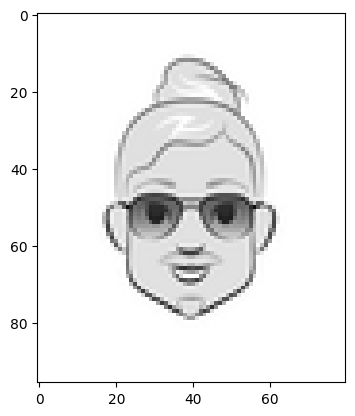

In [2]:
#@title Jeu de données : visages
!(test -e cartoonset10k.pkl && echo "Fichier prêt") || (wget https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/cartoonset10k.pkl.gz -O cartoonset10k.pkl.gz && gunzip "cartoonset10k.pkl.gz")

import matplotlib.pyplot as plt

def imshow(matrice, titre="(Image sans titre)", subplot=None):
  axis = plt
  if subplot is not None:
    axis = subplot
  matrice = np.clip(matrice, 0, 1)
  axis.imshow(matrice, cmap="gray", vmin=0, vmax=1)
  if subplot is None:
    axis.title(titre)
    axis.show()

import pickle
with open("cartoonset10k.pkl", "rb") as f:
    faces = [x for x in pickle.load(f)] # Liste python de matrices numpy


HAUTEUR_IMG, LARGEUR_IMG = faces[0].shape

faces = np.array([i.reshape(-1) for i in faces])
print("Shape du tableau de visages:", faces.shape)


def imshow_visage(img, titre=None):
  imshow(img.reshape(HAUTEUR_IMG, LARGEUR_IMG), titre)

imshow_visage(faces[0])

Quand on les prend tels quels, le jeu de données contient $96*80 = 7680$ pixels = **7680 dimensions par observation**.

Est-ce qu'on a **réellement besoin** de toutes ces 7680 valeurs pour décrire correctement une de ces images? Probablement pas...

&nbsp;

**1. Parmi les pixels d'arrière-plan, il y en a qui sont toujours blancs, à travers toutes les images**

Certains pixels sur les côtés sont toujours blancs à travers toutes les images. On gaspille de l'espace en les notant :

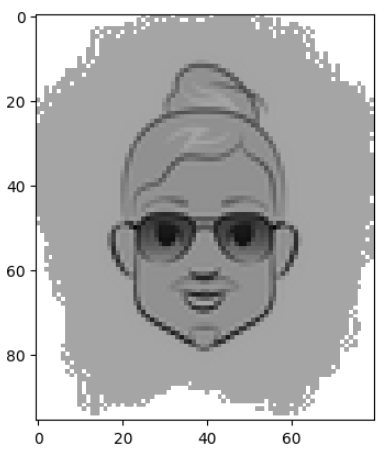

On peut compter combien de pixels ont une valeur constante (ie, *variance de zéro*), vite fait avec numpy ça nous donne :

In [67]:
print((faces.var(axis=0) == 0).sum())

1348


Il y a **1348 pixels dans chaque image qui sont constants**, soit un peu moins d'un cinquième de l'image.

Juste en retirant ces pixels de notre vecteur de pixels, on pourrait garder garder toute l'information importante, mais descendre à seulement **6332** dimensions, plutôt que 7680.

&nbsp;

**2. Il y a beaucoup de similarité dans les pixels**

Quelque chose d'un peu plus subtile qui peut être considéré : certains pixels sont très similaires à d'autres :

Dans ce jeu de données :

- Quand on connaît la couleur de l'oeil gauche, on connaît aussi la couleur de l'oeil droit
- Quand on connaît un des pixels de la joue, on en connaît aussi d'autres autour qui sont systématiquement de la même couleur.

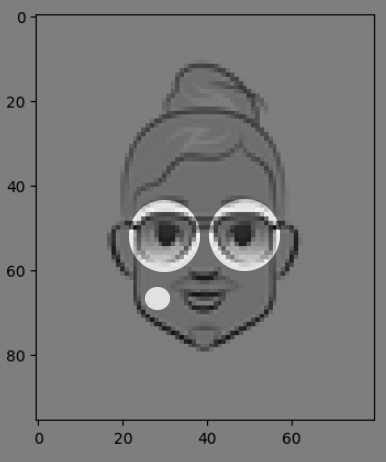

On avait justement profité de ça pour prédire la moitié droite d'un visage à partir de la moitié gauche. Quand on y pense un peu, notre régression Ridge au module 10, c'était un peu comme une façon d'apprendre à reconstruire $7680$ pixels à partir de seulement $7680/2 = 3840$ pixels.

Un dessin de visage pourrait être transformé en seulement 3840 dimensions et on aurait quand même la capacité de retrouver tous les pixels originaux avec ça.

&nbsp;

**3. Pixels vs Description de l'image à un haut niveau**

Les pixels des images, c'est ce qu'on possède, mais ce n'est pas la seule façon de réfléchir aux visages. En réalité, ce jeu de données est construit avec des combinaisons d'un petit nombre de dessins :

&nbsp;&nbsp;&nbsp;&nbsp;**1.** 10 couleurs de cheveux possibles

&nbsp;&nbsp;&nbsp;&nbsp;**2.** 111 sortes de coiffure

&nbsp;&nbsp;&nbsp;&nbsp;**3.** 12 sortes de lunettes

&nbsp;&nbsp;&nbsp;&nbsp;**4.** 5 couleurs d'yeux


...

&nbsp;&nbsp;&nbsp;&nbsp;**17.** 7 formes de visages

&nbsp;&nbsp;&nbsp;&nbsp;**18.** 11 couleurs de peau

&nbsp;

En théorie, avec aussi peu que **18 nombres**, on pourrait avoir toute l'information requise pour reconstruire une image de visage au complet :

```
  visage =
  -  couleur de cheveux #2 sur 10
  -  sorte de coiffure #83 sur 111
  -  sorte de lunettes #9 sur 12
  -  couleur d'yeux #2 sur 5
  -  ...
  -  forme de visages #5 sur 7
  -  couleur de peau #3 sur 11

  => visage = [2, 83, 9, 2, ... 5, 3], vecteur de 18 dimensions
```

&nbsp;

On va tenter de faire une réduction de dimensionnalité apprise automatiquement à partir des données.

## Auto-encodeur

L'**auto-encodeur** est une architecture de réseau de neurones qui permet de faire de l'apprentissage **non-supervisé** pour de la réduction de dimensionalité.

L'idée est très simple : on demande à un réseau de neurone qui reçoit $X$ en entrée de prédire $X$ en sortie.

Littéralement :

```python
modele = MLPRegressor(...)

modele.fit(X, X) # <------- on utilise X pour re-prédire X
```

Par exemple :

```python
modele = MLPRegressor(...)

modele.fit(visages, visages)
# => On prend en entrée X = les 7860 pixels de visages
# => On apprend à prédire X = ces mêmes 7860 pixels
```

&nbsp;

## Pourquoi on ferait ça?

Si on entraînait une régression linéaire à faire ça, ça n'aurait aucun sens. Les coefficients appris seraient tous à 1, on recopie en sortie la valeur d'entrée et on n'a rien appris d'utile.

On va plutôt faire ça avec un réseau de neurones **avec au moins une couche cachée dont la dimension est plus petite que les données d'entrée**. Par exemple, si on avait 10 dimensions en entrée, on pourrait utiliser une couche cachée de seulement 5 dimensions :

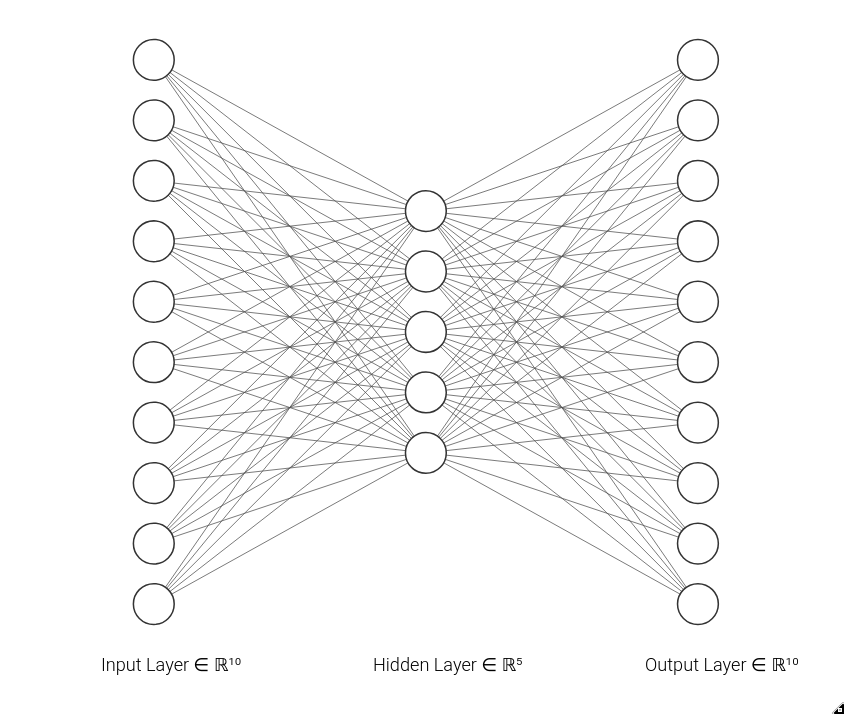

Le réseau va donc produire des résultats intermédiaires :

- Couche d'entrée = donnée originale
- Couche cachée = chaque neurone prédit une valeur basée sur l'image d'entrée
- Couche de sortie = chaque neurone fait une régression sur les valeurs de la couche cachée pour tenter de reproduire la donnée originale

On va alors pouvoir **s'intéresser les valeurs intermédiaires produites par les neurones de la couche cachée**.

Si le réseau de neurones réussit à faire cette tâche, c'est que la dimension de la petite couche cachée est suffisante pour représenter correctement nos données, avec moins de dimensions qu'au départ.


## Architecture de l'auto-encodeur

On peut voir le réseau de neurones auto-encodeur en deux étapes :

1. L'encodage : les données d'entrées sont transformées en un vecteur plus petit
2. Le décodage : le petit vecteur est retransformé en la valeur originale

&nbsp;

En pratique, utiliser plus qu'une seule couche cachée peut être une bonne idée. L'encodeur va transformer l'entrée pour réduire sa dimension jusqu'à atteindre la couche la plus mince :

*Encodage graduel de 10 dimensions vers seulement 2 dimensions, puis décodage graduel vers 10 dimensions*

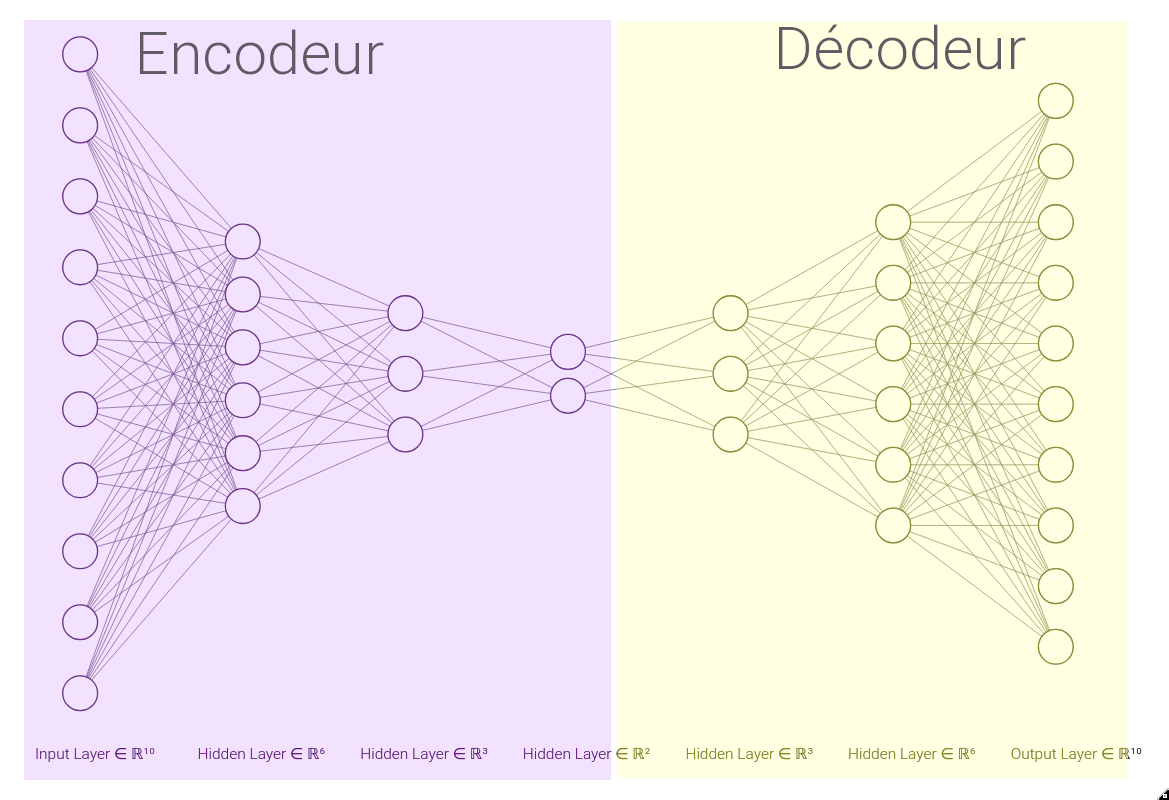

## Entraîner un auto-encodeur sur les dessins de visages

On va entraîner un réseau de neurones à encoder nos images de visages de gens (96x80 pixels = 7680 dimensions d'entrée) en des vecteurs de seulement **256** dimensions, puis à décoder ces petits vecteurs pour ré-obtenir les visages originaux.

&nbsp;

En faisant un `partial_fit()` sur nos données, on va voir comment le réseau apprend graduellement à encoder et décoder un visage.

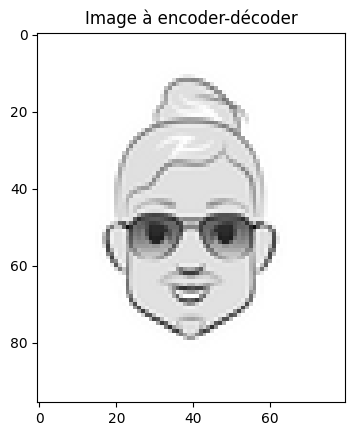

=== Époque 0 ===


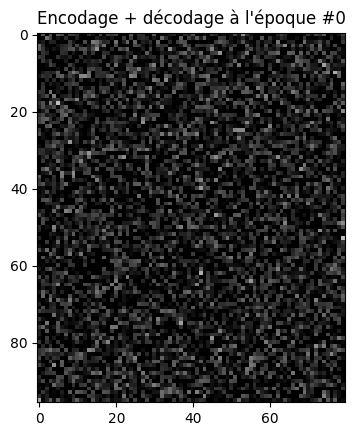

=== Époque 1 ===


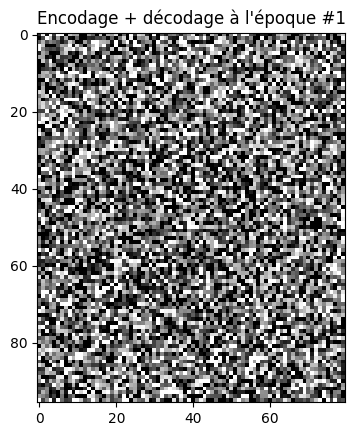

=== Époque 2 ===


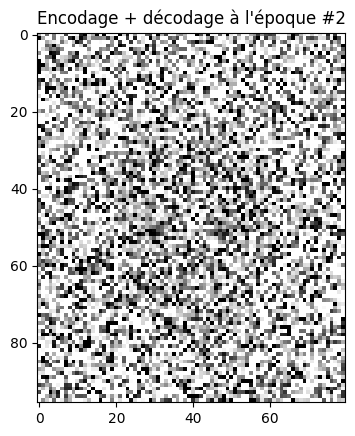

=== Époque 3 ===


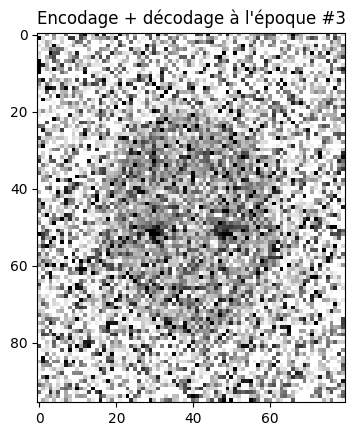

=== Époque 4 ===


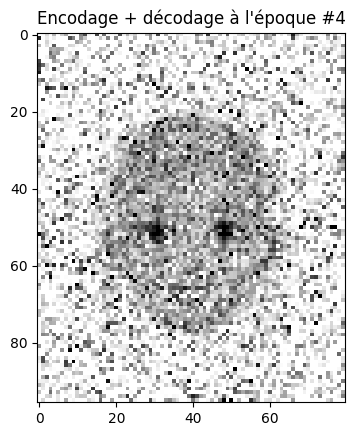

=== Époque 5 ===


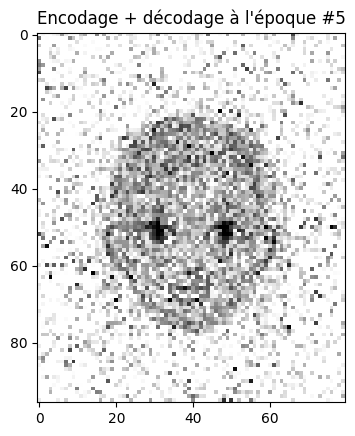

=== Époque 6 ===


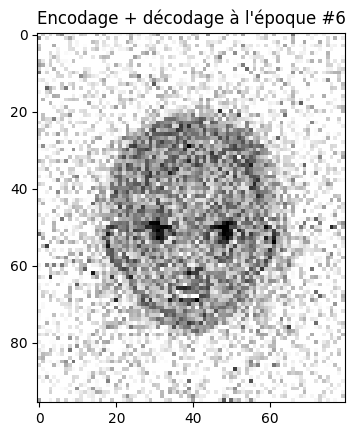

=== Époque 7 ===


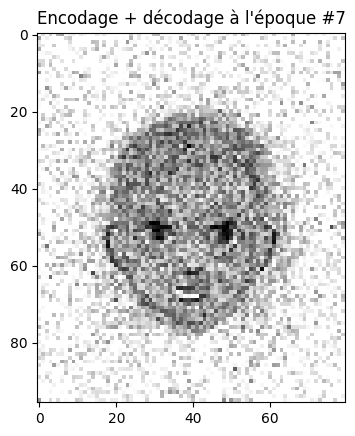

=== Époque 8 ===


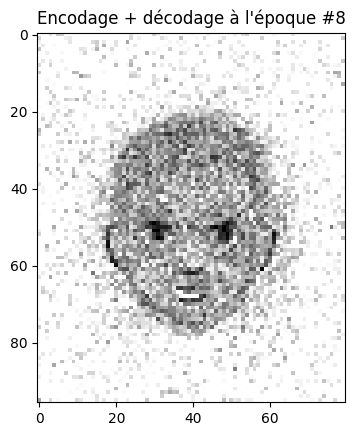

=== Époque 9 ===


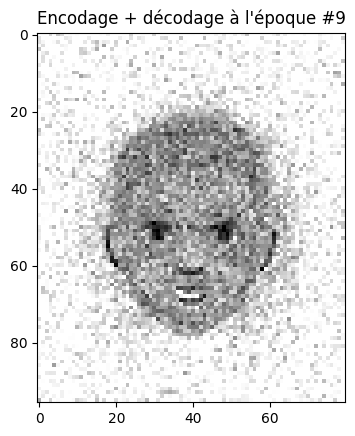

In [3]:
#@title Entraînement d'un autoencodeur

petit_autoencodeur = MLPRegressor((2500, 1500, 500, 1500, 2500), 'relu', learning_rate_init=0.0001, random_state=1337)

petit_faces = faces[:300]

imshow(petit_faces[0].reshape(HAUTEUR_IMG, LARGEUR_IMG), "Image à encoder-décoder")

for epoque in range(10):
  print("=== Époque", epoque, "===")
  petit_autoencodeur.partial_fit(petit_faces, petit_faces) # On prédit les visages à partir des visages

  prediction = petit_autoencodeur.predict(petit_faces[0:1])
  imshow(prediction[0].reshape(HAUTEUR_IMG, LARGEUR_IMG), f"Encodage + décodage à l'époque #{epoque}")

## Réseau pré-entraîné

L'entraînement d'un réseau de neurones sur ce problème est beaucoup trop long pour qu'on fasse ça en classe (ça ne serait pas tellement intéressant de regarder ça aller pendant 2h). J'ai pré-entraîné un réseau pendant quelques heures sur un GPU, vous pouvez le télécharger avec la cellule suivante.

C'est celui-là qu'on va utiliser dans nos expérimentations.

In [3]:
#@title Téléchargement du modèle
import os
if 'autoencodeur-faces-sklearn.pkl' not in os.listdir():
  !wget https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/xaa.autoencodeur-faces-sklearn.pkl.gz
  !wget https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/xab.autoencodeur-faces-sklearn.pkl.gz
  !wget https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/xac.autoencodeur-faces-sklearn.pkl.gz
  !wget https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/xad.autoencodeur-faces-sklearn.pkl.gz
  !cat xa{a,b,c,d}.autoencodeur-faces-sklearn.pkl.gz > autoencodeur-faces-sklearn.pkl.gz
  !gunzip autoencodeur-faces-sklearn.pkl.gz
  !rm xa{a,b,c,d}.autoencodeur-faces-sklearn.pkl.gz
else:
  print("Fichier prêt")

--2026-05-05 14:00:41--  https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/xaa.autoencodeur-faces-sklearn.pkl.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 94371840 (90M) [application/octet-stream]
Saving to: ‘xaa.autoencodeur-faces-sklearn.pkl.gz’

xaa.autoencodeur-fa 100%[===================>]  90.00M   403MB/s    in 0.2s    

2026-05-05 14:00:42 (403 MB/s) - ‘xaa.autoencodeur-faces-sklearn.pkl.gz’ saved [94371840/94371840]

--2026-05-05 14:00:42--  https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/xab.autoencodeur-faces-sklearn.pkl.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)

In [4]:
#@title Chargement du modèle en mémoire
import pickle

with open('autoencodeur-faces-sklearn.pkl', 'rb') as f:
  autoencodeur = pickle.load(f)

print("=== Configuration ===")
print(autoencodeur)
print("- Couche d'entrée:", autoencodeur.coefs_[0].shape[0], "caractéristiques")
print("- Couches cachées:", autoencodeur.hidden_layer_sizes)
print("- Fonction d'activation des couches cachées:", autoencodeur.activation)
print("- Couche de sortie: 1 neurone, fonction d'activation finale:", autoencodeur.out_activation_)
print()

=== Configuration ===
MLPRegressor(activation='tanh',
             hidden_layer_sizes=(3840, 1920, 1024, 512, 256, 512, 1024, 1920,
                                 3840))
- Couche d'entrée: 7680 caractéristiques
- Couches cachées: (3840, 1920, 1024, 512, 256, 512, 1024, 1920, 3840)
- Fonction d'activation des couches cachées: tanh
- Couche de sortie: 1 neurone, fonction d'activation finale: identity



/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


**Exercice**

Combien y a-t-il de paramètres appris dans ce modèle?

**VOTRE RÉPONSE ICI**


In [5]:
#@title Vérification du modèle

def afficher(i=0):
  prediction = autoencodeur.predict(faces[i:i+1])[0]
  imshow_visage(faces[i], f"Visage #{i}")
  imshow_visage(prediction, f"Encodage + décodage du visage #{i}")

from ipywidgets import interact

out = interact(afficher, i=(0, len(faces)-1))

interactive(children=(IntSlider(value=0, description='i', max=9999), Output()), _dom_classes=('widget-interact…

La plus petite couche cachée de ce modèle ne contient que **256 valeurs**.

Le réseau commence donc avec 7680 pixels, puis les transforme graduellement jusqu'à avoir un vecteur de seulement 256 dimensions.

# Qu'est-ce qu'on fait avec un autoencodeur?

Une fois qu'on a appris à reconstruire une image, il y a plein d'applications intéressantes.

## Application 1: Réparer des images brisées

On n'a pas entraîné notre réseau sur n'importe quoi : on lui a demandé **d'apprendre à faire des visages spécifiquement**.

Un visage modifié d'une façon un peu drastique, si on demandait à notre réseau de l'encoder et le décoder, ça devrait nous redonner quelque chose qui ressemble à un visage du jeu d'entraînement.

In [ ]:
#@title Exercice 1 : Essayez de modifier des bouts de l'image pour voir ce qui arrive

# Remplacer un petit carré de l'image par du gris
image_brisee = faces[0].copy().reshape(HAUTEUR_IMG, LARGEUR_IMG)

# TODO : Remplacez l'oeil gauche par un carré de gris (valeur = 0.6)
# pour voir ce qui se passe quand on redonne cette image à l'autoencodeur

image_brisee[1, 2] = 0.6

############


############ tests

image_brisee = image_brisee.reshape(-1)

imshow_visage(image_brisee, "Image modifiée")

prediction = autoencodeur.predict([image_brisee])[0]
imshow_visage(prediction, "Prédiction à partir de l'image modifiée")



In [ ]:
#@title Exercice 2 : Ajoutez du bruit avec np.random.random(shape de l'image)

# Remplacer un petit carré de l'image par du gris
image_brisee = faces[0].copy()

# TODO: Ajoutez du random sur les pixels
# Commencez par ajouter une valeur au hasard entre -0.05 et +0.05 sur chaque pixel,
# puis essayez avec plus de bruit : -0.25 à +0.25

############


############ tests

image_brisee = image_brisee.reshape(-1)

imshow_visage(image_brisee, "Image modifiée")

prediction = autoencodeur.predict([image_brisee])[0]
imshow_visage(prediction, "Prédiction à partir de l'image modifiée")



## Application 2: Détection d'anomalies

Comme on vient de le dire, la seule chose que notre réseau de neurones sait faire, c'est des images de visages... **Qu'est-ce qui se passe si on lui donne une image d'autre chose en entrée?**

In [ ]:
#@title Exercice 3

# Qu'est-ce qui se passe quand on prend une image toute noire, ou
# encore une image toute blanche ?

image_noire = ...
image_blanche = ...

#######

#########



Hmm...

Essayons avec d'autres sortes d'images qui ne sont pas des visages :

--2026-05-05 01:29:05--  https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/cartoon-not-face.pkl.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 26443472 (25M) [application/octet-stream]
Saving to: ‘cartoon-not-face.pkl.gz’

cartoon-not-face.pk 100%[===================>]  25.22M   155MB/s    in 0.2s    

2026-05-05 01:29:05 (155 MB/s) - ‘cartoon-not-face.pkl.gz’ saved [26443472/26443472]



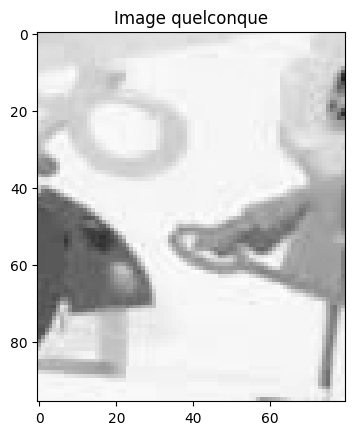

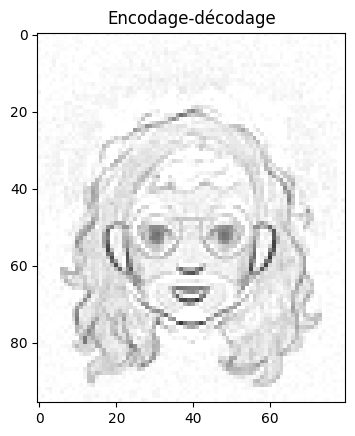

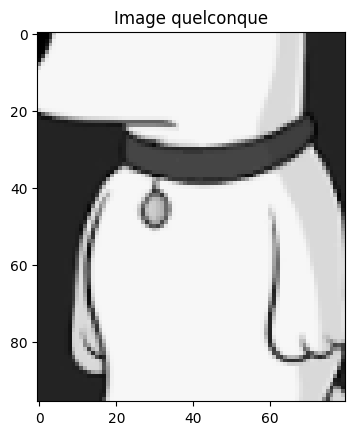

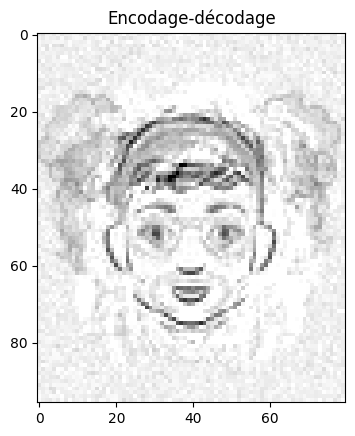

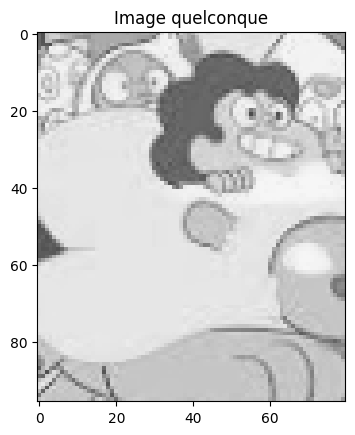

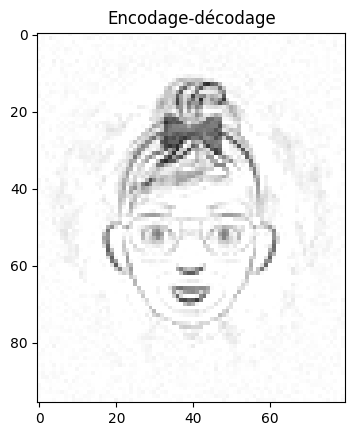

In [10]:
#@title Téléchargement d'images qui ne sont pas des visages
!(test -e cartoon-not-face.pkl && echo "Fichier prêt") || (wget https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/cartoon-not-face.pkl.gz -O cartoon-not-face.pkl.gz && gunzip "cartoon-not-face.pkl.gz")

with open("cartoon-not-face.pkl", "rb") as f:
    non_faces = np.array([x.reshape(-1) for x in pickle.load(f)]) # Liste python de matrices numpy

predictions = autoencodeur.predict(non_faces[:3].reshape(3, -1))

for image, prediction in zip(non_faces[:3], predictions):
  print("=" * 90)
  imshow_visage(image, "Image quelconque")
  imshow_visage(prediction, "Encodage-décodage")

Quand la sortie ne ressemble pas du tout à l'entrée qu'on a fourni, **c'est un signe qu'on a probablement fourni quelque chose qui n'est pas un visage**.

&nbsp;

On peut se servir du réseau de neurones auto-encodeur pour faire de la **détection d'anomalies**. Quand on encode quelque chose et qu'on le décode, si la sortie ne ressemble pas à l'entrée, c'est que c'est fort probablement **une anomalie** : quelque chose qui ne ressemble pas aux données connues.

On peut donc assez facilement se faire un **détecteur de visages** :

1. On passe l'image à notre modèle pour lui demander de l'encoder et de la décoder (`modele.predict()`)
2. On calcule l'erreur RMSE de l'image reconstruite comparée à l'image originale
3. Si cette erreur RMSE est trop élevée, alors ce n'est probablement pas un visage


In [ ]:
#@title Exercice 4

def est_un_visage(image, erreur_max=0.03):
  # TODO: Utiliser l'erreur RMSE et comparer à erreur_max pour décider
  return True

#############

#############



### Comment on choisit le seuil d'erreur RMSE maximale pour dire que ce n'est pas un visage?

On peut y aller à tâtons... Mais si on testait plein d'images de visages et de non-visages et qu'on obtenait quelque chose comme :

```
Type       | Erreur rmse de la reconstruction
=============================================
visage     | 0.034772
visage     | 0.037821
visage     | 0.047129
visage     | 0.021172
pas visage | 0.247822
pas visage | 0.321174
pas visage | 0.1591217
pas visage | 0.0942413
pas visage | 0.92117377
pas visage | 0.1787616
pas visage | 0.05726613
```

C'est un **jeu de données ça**... On peut **entraîner un modèle simple sur ces données, par exemple un SVM**.

In [12]:
resultats = []

predictions_faces = autoencodeur.predict(faces)
predictions_non_faces = autoencodeur.predict(non_faces)

for idx, (image, prediction) in enumerate(zip(faces, predictions_faces)):
  erreur = root_mean_squared_error(image, prediction)
  resultats.append([1, erreur, idx])

for idx, (image, prediction) in enumerate(zip(non_faces, predictions_non_faces)):
  erreur = root_mean_squared_error(image, prediction)
  resultats.append([0, erreur, len(predictions_faces) + idx])

erreurs = pd.DataFrame(resultats, columns=['est_un_visage', 'rmse', 'idx'])

erreurs_entrainement, erreurs_test = train_test_split(erreurs, random_state=1337)

classifieur_visages = LinearSVC()

classifieur_visages.fit(erreurs_entrainement[['rmse']], erreurs_entrainement.est_un_visage)

predictions = classifieur_visages.predict(erreurs_test[['rmse']])

print("Exactitude du détecteur de visages basé sur l'erreur RMSE:", accuracy_score(erreurs_test.est_un_visage, predictions))

Exactitude du détecteur de visages basé sur l'erreur RMSE: 0.9996902106567535


## Interprétabilité du modèle et des cas d'échecs

On a des excellents résultats pour la détection de visages (> 99.9%), mais il reste tout de même quelques rares cas d'échec

L'image suivante n'est pas détectée correctement par notre modèle :

,predictions,truth,idx
11272,1,0,11272


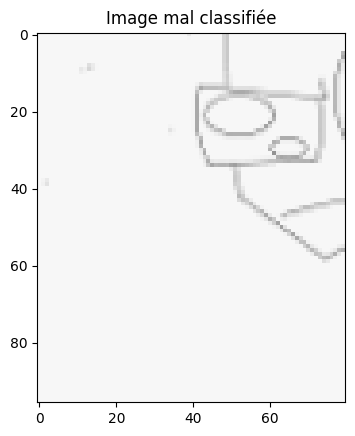

In [13]:
df = pd.DataFrame({"predictions": predictions, "truth": erreurs_test.est_un_visage, "idx": erreurs_test.idx})
display(df[df.predictions != df.truth])

index = df[df.predictions != df.truth].iloc[0].idx
imshow_visage(np.concat([faces, non_faces])[index], "Image mal classifiée")

**Pourquoi?**

Eh bien...

`=>` **Parce que c'est ce qui réduisait l'erreur sur notre jeu de données**

&nbsp;

On est très très loin d'avoir une explication claire quand on fait face à un cas d'échec.

## C'est quoi une *"anomalie"*?

Une anomalie, dans ce modèle, c'est quelque chose qui ne ressemble pas assez à nos données d'entraînement pour être correctement encodé et re-décodé avec une petite erreur.

C'est "**tout ce qui est trop différent de ce qu'on connaît déjà**".

&nbsp;

**Si nos données ne sont pas assez diversifiées, ça peut vite poser problème**. (Lire: https://www.mozillafoundation.org/en/blog/facial-recognition-bias/)

Considérez la photo suivante :

![](https://upload.wikimedia.org/wikipedia/commons/thumb/f/f6/FACE_TATTOO_RAMNAMI_TRIBE_02.jpg/330px-FACE_TATTOO_RAMNAMI_TRIBE_02.jpg?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail)

Est-ce que ça c'est une "anomalie" quand on considère des visages de personnes?

Si notre jeu de données n'a pas ou très très peu d'exemples qui ressemblent à ça, notre détecteur va l'identifier comme quelque chose qui n'est pas un visage...

&nbsp;

Avec cette approche, on peut facilement se construire un **modèle avec des biais, sans s'en rendre compte**.

En particulier : des groupes de gens sous-représentés dans nos données peuvent devenir des cas d'échecs systématiques pour notre modèle.

&nbsp;

Un cas d'échec systématique pour certains groupes de personnes, c'est ce qu'on appelle **de la discrimation**. Si des policiers se servent de modèles d'IA pour identifier des criminels potentiels, un biais racial dans les données (ex.: surreprésentation d'un certain groupe dans les exemples de personnes arrêtées) va encourager le modèle à apprendre à discriminer.

## D'où proviennent les données?

On n'a pas le choix : les données doivent provenir du monde dans lequel on vit.

Si les seules données qu'on possède sur l'interpellation d'individus proviennent de policiers du SPVM et que ces données incluent des cas où les policiers faisaient du profilage racial (je ne lance pas une idée hypothétique ici, lisez https://www.lapresse.ca/actualites/justice-et-faits-divers/2024-09-03/la-ville-de-montreal-devra-indemniser-les-victimes-de-profilage-racial-par-les-policiers.php), alors **une IA entraînée sur ces données va être encouragée à apprendre à faire du profilage racial**.

&nbsp;

Il n'y a pas de solution simple ici. **Les biais de la société vont souvent se retrouver dans les données qu'on arrive à obtenir.**

Si la collecte de données est biaisée, nos données (et donc nos modèles) seront biaisés. Collecter plus de données avec la même méthode ne règlera pas le problème.

&nbsp;

## Dépixelliseur

En 2020, [un *"Dépixelliseur d'images"* a fait le tour des réseaux sociaux](https://www.vice.com/en/article/this-image-of-a-white-barack-obama-is-ais-racial-bias-problem-in-a-nutshell/). Ce modèle d'IA prennait en entrée une image de visage pixelisée et **imaginait** un visage qui **aurait pu** être à l'origine (beaucoup de détails ne peuvent évidemment pas être réellement retrouvés, donc on parle vraiment d'*inventer quelque chose de plausible*) :

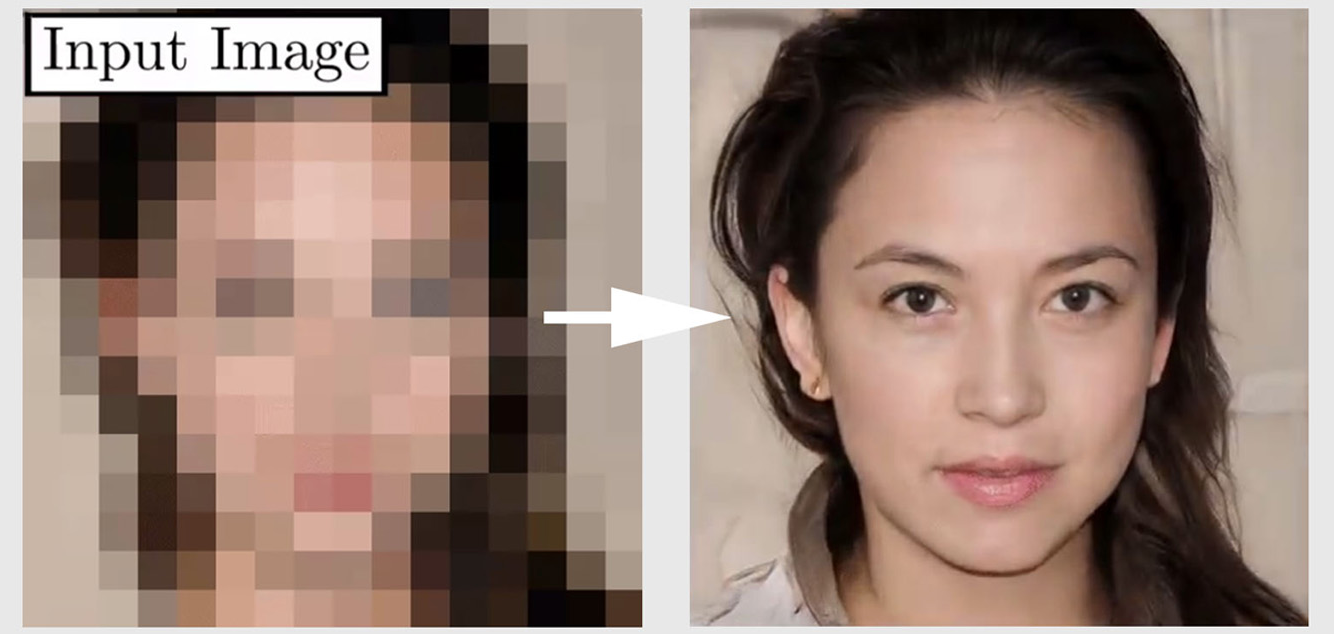

Certaines personnes se sont rendu compte que le réseau de neurones produisait dans beaucoup de cas *des personnes blanches*, même quand ça n'avait pas de sens.

Voici ce que le modèle donnait comme résultat quand on lui fournissait une photo de Barack Obama :

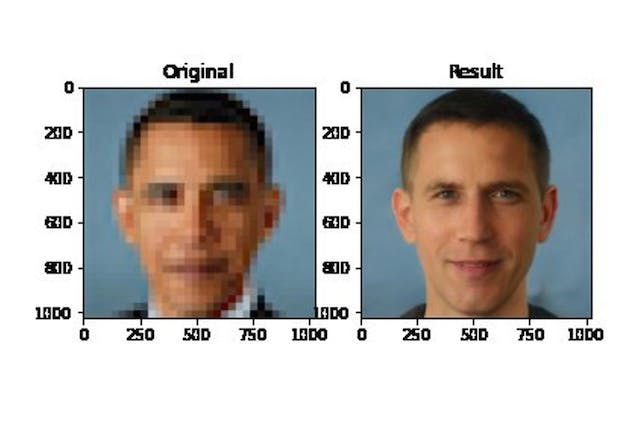

D'autres tests montraient qu'un biais racial était bien présent :

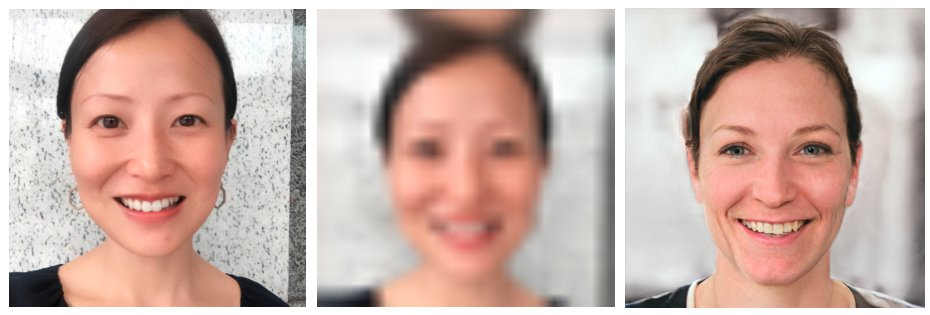

## Le rose, le bleu et ChatGPT

**Un biais présent dans la société va finir par se rendre dans les données d'entraînement et se faire apprendre par le modèle.**

&nbsp;

Voici un petit test : j'ai demandé à *ChatGPT-5mini* à répétition

> **prompt**: J'ai envie de jouer à un jeu de rôle! Peux-tu m'imaginer quelqu'un qui adore le rose? Fais-moi une description de base en 4 phrases maximum

&nbsp;

Voici les réponses pour 10 tentatives (une nouvelle conversation est démarrée à chaque *prompt*) :

- Elle s'appelle Lila, toujours vêtue de nuances de rose du fuchsia au poudré. Sa chambre ressemble à un cocon: peluches, guirlandes et posters floraux. Elle collectionne des objets rétro roses et crée des DIY gourmands et colorés. Optimiste et attentionnée, elle voit la beauté dans les petits détails.
- Elle s'appelle Camille, cheveux roses poudrés coupés en carré et lunettes rondes assorties. Toujours en tenue rose — veste en velours, baskets et vernis — elle collectionne les petits accessoires vintage. Enthousiaste et généreuse, elle transforme chaque salon en fête bonbonnière. Elle parle avec des métaphores colorées et aime offrir des fleurs et des confiseries.
- Elle s'appelle Camille, toujours vêtue de nuances de rose — du vieux rose au fuchsia éclatant — et collectionne des rubans, vernis et accessoires assortis. Son appartement respire le rose : murs poudrés, coussins en satin et une bibliothèque peinte en rose bonbon. Optimiste et chaleureuse, elle offre des compliments sincères et organise des goûters colorés pour ses amis. Même son carnet de notes est couvert de stickers et de dessins floraux roses.
- Elle s'appelle Lila, une créatrice de 27 ans toujours vêtue de nuances de rose, du fuchsia au pastel. Son appartement est un refuge rose poudré rempli de coussins, de fleurs et d'art mural fait main. Elle a une énergie chaleureuse et enthousiaste, adore les boissons sucrées et collectionne les accessoires kawaii. Curieuse et loyale, elle transforme chaque moment ordinaire en petite fête colorée.
- Elle s'appelle Lila, une créatrice de mode pétillante dont chaque tenue est un hymne au rose — du fuchsia éclatant au pastel délicat. Ses cheveux sont teints en dégradé rose, elle porte toujours des accessoires en cœur et un sac en velours rose poudré. Optimiste et généreuse, elle transforme les petits gestes du quotidien en moments doux et colorés. Même ses notes et son appartement reflètent sa signature rose, créant une atmosphère chaleureuse et féminine.
- Elle s'appelle Lila, une créatrice de mode pétillante qui porte toujours des tenues entièrement roses — du manteau en laine aux chaussures vernies. Ses cheveux sont teints en dégradé rose bonbon et elle collectionne des accessoires rétro scintillants. Son appartement est un cocon rose poudré rempli de tissus, de plantes et de posters vintage. Optimiste et chaleureuse, elle transforme chaque détail du quotidien en petite fête colorée.
- Elle s'appelle Lila, porte toujours une jupe rose pétale et collectionne des accessoires à paillettes. Sa chambre est peinte en dégradé rose avec des coussins en forme de coeurs et une guirlande lumineuse. Enthousiaste et chaleureuse, elle offre des compliments sincères à tout le monde. Son rire est léger comme une clochette et elle adore organiser des goûters thématiques roses.
- Elle s'appelle Lila et porte toujours un kimono rose poudré, des boucles d'oreilles en forme de coeurs et un sac en velours framboise. Elle travaille comme décoratrice d'intérieur et a un instinct pour transformer les espaces ternes en cocons colorés. Son rire est léger, elle collectionne les carnets à couverture rose et boit toujours son thé dans une tasse à motifs floraux. Devant l'inconnu, elle reste optimiste et réchauffe les autres avec une généreuse dose de douceur rosée.
- Elle s'appelle Lila, porte toujours un blazer rose fuchsia et des lunettes à monture pâle. Son appartement est décoré de coussins, guirlandes et plantes en pots roses assortis. Elle collectionne les carnets et stylos rose bonbon et refuse d'acheter quoi que ce soit d'une autre couleur. Souriante et enthousiaste, elle transforme tout projet banal en une fête pastel.
- Elle s’appelle Lila, aime les petites choses extravagantes et porte toujours au moins un accessoire rose vif. Sa chambre est tapissée de posters et de coussins roses, avec des touches dorées et des peluches alignées. Elle sourit facilement, parle avec enthousiasme de ses passions créatives et collectionne les vernis à ongles et les robes à volants. Malgré son apparence pétillante, elle est attentive, loyale et prête à défendre ses ami·e·s.

&nbsp;

Les descriptions sont toutes différentes (il y a une part de hasard dans la sortie de ChatGPT), mais on peut noter ce que ChatGPT a appris tout seul à associer à la couleur rose :

- C'est systématiquement un personnage féminin
- Elle s'appelle Lila, ou Camille
- Les peluches
- Les guirlandes
- Les fleurs
- Les bonbons
- Le vernis à ongles
- Des objets en forme de coeurs
- Elle est optimiste

&nbsp;

## Qui aime la bière?

Essayons autre chose, toujours avec le même ChatGPT-5mini

> **prompt**: J'ai envie de jouer à un jeu de rôle! Peux-tu m'imaginer quelqu'un qui adore la bière? Fais-moi une description de base en 4 phrases maximum

Le même prompt, mais avec **la bière** plutôt que **le rose**.

&nbsp;

Voici les réponses pour 10 tentatives (une nouvelle conversation est démarrée à chaque *prompt*) :

- Gustave, 34 ans, microbrasseur amateur au rire facile qui connaît par cœur les fiches de dégustation de chaque bière locale. Il collectionne des verres uniques, parle passionnément d'amertume et de fermentation, et apporte toujours une bouteille à partager lors des soirées. Loyal et chaleureux, il sait mettre les gens à l'aise — sauf quand on lui vole la dernière bière rare. Son odeur de houblon et sa casquette usée le rendent immédiatement reconnaissable.
- Il s'appelle Hugo, un amateur passionné de bières artisanales qui aime découvrir des microbrasseries locales. Il connaît les styles (IPA, stout, saison) et peut décrire l'arôme, la bouche et l'amertume avec précision. Toujours prêt à partager une nouvelle découverte, il collectionne aussi des verres et des sous-bocks originaux. Sa passion le rend curieux, sociable et toujours partant pour une dégustation entre amis.
- Il s'appelle Marco, un trentenaire chaleureux au rire facile qui collectionne les sous-bocks et connaît les microbrasseries locales sur le bout des doigts. Chaque vendredi soir, il organise des dégustations maison où il explique avec passion les profils d'amertume, les arômes et les accords mets-bières. Toujours prêt à partager une nouvelle découverte, il note tout dans un carnet froissé rempli d'étiquettes collées. Sous son air bon vivant, il apprécie surtout les conversations simples autour d'une pinte bien fraîche.
- Il s'appelle Marcel, la cinquantaine, nez souvent rosé et sourire facile, toujours prêt à recommander une bière locale. Il collectionne les sous-bocks et connaît par cœur les profils de houblons et les noms de brasseries artisanales. Le dimanche, on le trouve à une table en terrasse, une pils ou une IPA à la main, discutant fermentation et accords mets-bières. Fidèle mais curieux, il n'hésite pas à goûter chaque nouvelle microbrasserie qui ouvre en ville.
- Il s'appelle Maxime : amateur passionné de bières artisanales, il collectionne les étiquettes et note chaque dégustation dans un carnet usé. Toujours prêt à recommander une IPA sombre ou une lager bien froide, il connaît les microbrasseries locales par cœur. Son rire est contagieux autour d'une table de dégustation, où il raconte des anecdotes de voyages brassicoles. Curieux et convivial, il aime partager sa découverte du jour avec enthousiasme.
- Il s’appelle Luc, la trentaine, amateur passionné de bières artisanales et toujours prêt à expliquer la différence entre un IPA et une stout. Son regard s’illumine devant une armoire à bières bien garnie et il prend plaisir à noter arômes et houblons dans un petit carnet. Sociable et chaleureux, il organise régulièrement des dégustations entre amis où il fait découvrir des brasseries locales. Fidèle à ses habitudes, il porte souvent un t-shirt de sa brasserie préférée et une casquette légèrement usée.
- Il s'appelle Marc, il a la trentaine et collectionne les sous-bocks comme des trophées. Toujours partant pour une dégustation, il connaît par cœur les houblons et peut décrire une IPA comme un sommelier décrirait un grand cru. Son rire s'entend dès qu'on parle de brasseries locales et il organise des soirées "blind tasting" chaque mois. Malgré sa passion, il reste curieux et ouvert à découvrir de nouvelles saveurs.
- Il s'appelle Marcel, amateur passionné de bières artisanales qui collectionne les verres et note chaque dégustation dans un carnet usé. Toujours prêt à expliquer la différence entre une IPA et une stout, il parcourt les festivals locaux à la recherche de nouvelles brasseries. Rieur et sociable, il aime partager une pinte en racontant des anecdotes sur la fabrication du houblon. Son pull sent parfois légèrement le malt — et il en est fier.
- Il s'appelle Lucas, 34 ans, et collectionne des verres à bière du monde entier qu'il expose fièrement dans son salon. Chaque week-end il parcourt les microbrasseries locales pour déguster de nouvelles recettes et discuter longuement avec les brasseurs. Passionné par les saveurs, il peut décrire sans hésiter les notes de malt, d'amer et d'alcool d'une bière juste au premier verre. Sociable et chaleureux, il organise souvent des soirées dégustation où il partage ses découvertes et ses anecdotes brassicoles.
- Il s'appelle Marc, 34 ans, brasseur amateur le week-end et toujours partant pour une dégustation entre amis. Il connaît des dizaines de styles de bière, peut décrire un nez et une amertume avec précision, et collectionne les verres et étiquettes rares. Sociable et chaleureux, il adore raconter des anecdotes de festivals et recommander la bière parfaite pour chaque repas. Son rire est contagieux, et il garde toujours une petite note sur son carnet des nouveautés à tester.

&nbsp;

Celui qui aime les bières...

- Toujours un homme
- Hugo-Maxime-Luc-Marc-Lucas-Marcel-Marco est passionné
- Il est curieux
- Toujours prêt à expliquer quelque chose

&nbsp;

ChatGPT a clairement appris à faire des liens entre les concepts **tels qu'ils sont compris par notre société actuelle**. Selon les données fournies à ChatGPT pour son entraînement, il est très commun d'associer la bière aux hommes et le rose aux filles.

&nbsp;

**Gardez bien en tête que ces associations ne sont pas "naturelles", mais bien culturelles.** C'est des choses qui peuvent changer avec le temps et la société qui évolue.

Le rose n'a pas toujours été associé aux filles dans toutes les sociétés. Une petit citation tirée de (https://www.britannica.com/story/has-pink-always-been-a-girly-color)[https://www.britannica.com/story/has-pink-always-been-a-girly-color] :

> *In 1918 the trade publication Earnshaw’s Infants’ Department claimed the “**generally accepted rule is pink for the boys, and blue for the girls**. The reason is that pink, being a more decided and stronger color, is more suitable for the boy, while blue, which is more delicate and dainty, is prettier for the girl.”*

&nbsp;

Les données d'entraînement proviennent d'une source qui est ancrée quelque part culturellement et qui comporte des biais spécifiques.

## Application 3: Compression des données

L'auto-encodeur, ça apprend à **compresser les données spécifiques à notre problème**.

Si j'ai 10 000 images de visages, qui ont chacune besoin de 96*80 pixels, en supposant que chaque pixel demande 4 bytes d'espace disque (la taille d'un `float`), ça occupe : $10~000 * 96*80 * 4 = 307~200~000$ bytes = **307.2Mb**.

Si je compresse chacune de ces images en seulement 256 floats, j'arrive plutôt à : $10~000 * 256 * 4 = 10~240~000$ bytes = seulement **10.2Mb**, soit environ 3% de l'espace initialement requis.

&nbsp;

Pour ravoir une image complète, on n'aura qu'à utiliser le décodeur de notre réseau de neurones.

## Extraire le petit vecteur produit par la couche cachée du milieu

La formulation mathématique d'un réseau de neurones est assez simple, chaque neurone est une combinaison linéaire + une fonction d'activation.

Chaque neurone a des coefficients + une ordonnée à l'origine, qui sont utilisés avec les données produites par la couche précédente.

On peut demander la liste des coefficients pour chaque couche avec :

In [8]:
# Une liste python contenant des matrices numpy
print(autoencodeur.coefs_[0]) # première couche cachée: une matrice numpy de shape N entrées x M neurones
print(autoencodeur.coefs_[0][5, 8]) # 5ème coefficient du 8ème neurone

[[ 0.00513151 -0.00557866  0.00858306 ... -0.00880671  0.00739989
  -0.00316904]
 [ 0.00158464  0.00190311  0.00410123 ... -0.0078101  -0.00086695
  -0.01034635]
 [ 0.00279842  0.00156294  0.00081962 ... -0.00679779  0.00454745
   0.00699923]
 ...
 [-0.00034294  0.00468783  0.00773667 ... -0.00030213  0.00219197
   0.00295424]
 [ 0.00096104  0.00393765  0.00441581 ...  0.00262255 -0.01161808
   0.00627985]
 [-0.0017246   0.00363467 -0.00781947 ...  0.00615669  0.002183
  -0.00704003]]
-0.0038738402


Les ordonnées à l'origine des neurones de chaque couche sont disponibles avec :

In [9]:
print(autoencodeur.intercepts_[0]) # première couche cachée: un tableau numpy de taille N entrées (il y a une seule ordonnée à l'origine par neurone)
print(autoencodeur.intercepts_[0][3]) # ordonnée à l'origine du 3ème neurone

[ 0.00629688 -0.00338532 -0.00626628 ... -0.00974742 -0.00257229
 -0.00499211]
-0.009431482


**Exercice**

Faites une fonction qui calcule les valeurs de sortie de la première couche cachée du réseau.

Ce modèle utilise la fonction d'activation $tanh$ (donc `np.tanh()`).

Chaque neurone a donc pour valeur de sortie quelque chose comme :

$$\text{neurone} = tanh(m_1 x_1 + m_2 x_2 + \ldots + b)$$

où les $x_i$ sont les pixels d'une image passée en entrée

&nbsp;

Pour faire la somme pondérée, vous avez deux options :

1. Utilisez une boucle pour faire le calcul

$$m_1 x_1 + m_2 x_2 + \ldots + m_N x_N + b$$

2. Si vous suivez le cours d'algèbre linéaire en ce moment, **essayez d'utiliser un produit matriciel avec la fonction `np.dot(vecteur, matrice)`**

In [ ]:
#@title Exercice 5: Propager les valeurs des pixels dans la couche 1 du réseau de neurones

def propager_valeurs(entree, coefficients, ordonnees_a_lorigine):
  pass

####################


################### tests

pixels = faces[0]
print(propager_valeurs(pixels, autoencodeur.coefs_[0], autoencodeur.intercepts_[0]))



Une fois que c'est fait, la cellule suivante va utiliser votre fonction pour **passer les pixels à travers toutes les couches de l'encodeur**, puis **à travers toutes les couches du décodeur**.

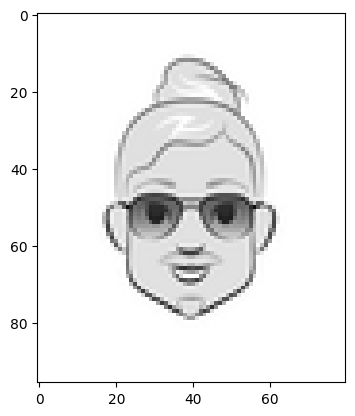

Shape du petit vecteur obtenu: (256,)
[-0.09056584  0.30906038 -0.32118013 -0.02202306 -0.03178804  0.3821418
  0.6746703   0.05319573  0.17187363  0.18835367  0.24828291  0.35622296
 -0.14022484  0.05521322  0.41723606 -0.25206736 -0.2201806   0.08538615
 -0.29691269  0.34446229 -0.21128426 -0.10410693 -0.00943377  0.22164204
  0.00856161 -0.48772359  0.25540491  0.29588472 -0.09087518  0.003904
  0.1359959   0.17550234  0.40752808 -0.1425739   0.28771976  0.14708108
 -0.57379974 -0.12926687 -0.60505798 -0.06116437  0.35508486 -0.18021316
  0.40938954 -0.03356626  0.09796708  0.35224005  0.64374821 -0.21656258
 -0.29589503  0.42357577  0.16188676  0.33248308 -0.25186962  0.11748205
  0.20051201  0.54268015 -0.30723841  0.20305702 -0.45717073  0.12855945
  0.07715712 -0.39119653 -0.58635429 -0.38201835  0.77440868  0.04319963
 -0.01705253  0.35407141 -0.22805177  0.20139275  0.41530547  0.04159916
  0.19435749 -0.16185474 -0.34239054 -0.93725221  0.15891678 -0.50356117
  0.26564202 -0.

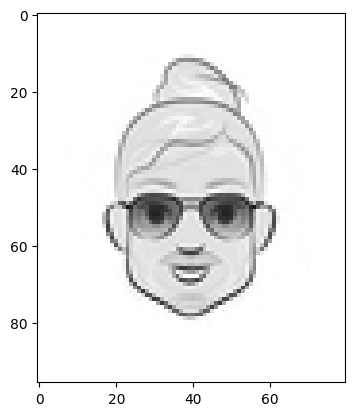

In [11]:
def encoder(image):
  # Encodeur = faire passer à travers toutes les couches, jusqu'à la plus petite
  numero_plus_petite_couche = np.argmin(autoencodeur.hidden_layer_sizes)

  valeurs = image

  for i in range(numero_plus_petite_couche + 1):
    valeurs = propager_valeurs(valeurs, autoencodeur.coefs_[i], autoencodeur.intercepts_[i])

  assert len(valeurs) == autoencodeur.hidden_layer_sizes[numero_plus_petite_couche]

  return valeurs

def decoder(encodage):
  # Encodeur = faire passer à travers toutes les couches, jusqu'à la plus petite
  numero_plus_petite_couche = np.argmin(autoencodeur.hidden_layer_sizes)

  valeurs = encodage

  for i in range(numero_plus_petite_couche + 1, len(autoencodeur.hidden_layer_sizes)):
    valeurs = propager_valeurs(valeurs, autoencodeur.coefs_[i], autoencodeur.intercepts_[i])

  # Dernière couche: pas de fonction d'activation tanh
  valeurs = np.dot(valeurs, autoencodeur.coefs_[-1]) + autoencodeur.intercepts_[-1]

  return valeurs


# Afficher l'image
imshow_visage(faces[0])

# Afficher un vecteur encodé avec encoder(image)
petit_vecteur = encoder(faces[0])
print("Shape du petit vecteur obtenu:", petit_vecteur.shape)
print(petit_vecteur)

# Décoder ce vecteur et réafficher l'image
prediction = decoder(petit_vecteur)
imshow_visage(prediction)

## Application 4: Générer des nouveaux visages

Qu'est-ce qui se passe si on **tire 256 valeurs au hasard et qu'on les décode?**

Notre décodeur a appris à refaire des visages...

Voyons voir :

In [56]:
def ajouter_hasard(seed=1, moyenne=0, ecart_type=0.2):
  np.random.seed(seed)
  petit_vecteur = np.random.normal(moyenne, ecart_type, size=(256,))

  # Décoder ce vecteur et réafficher l'image
  prediction = decoder(petit_vecteur)
  imshow_visage(prediction)

out = interact(
    ajouter_hasard,
    seed=(0, 999999),
    moyenne=(-0.3, 0.3, 0.01),
    ecart_type=(0.0, 1),
)

interactive(children=(IntSlider(value=1, description='seed', max=999999), FloatSlider(value=0.0, description='…

On obtient **des visages au hasard**.

L'auto-encodeur est l'architecture à la base de certains vieux modèles génératifs (à lire si ça vous intéresse: https://mayberay.bearblog.dev/generating-human-faces-with-variational-autoencoders/).

&nbsp;

On remarque tout de même que l'image n'est pas spécialement belle...

**Voici une autre idée** : comme on l'a vu plus haut, notre auto-encodeur est capable de **réduire le bruit dans une image**... On pourrait :

1. Partir avec un vecteur de 256 valeurs tirées au hasard
2. Décoder ce vecteur
3. Ajouter **un peu de bruit au hasard**
4. Passer cette nouvelle image dans notre auto-encodeur
5. Recommencer les étapes 3 et 4 un certain nombre de fois

In [57]:
def tirer_au_hasard(moyenne=-0.25, ecart_type=0.20, bruit=0.15, seed=201718, iters=8):
  # petit_vecteur = encoder(faces[numero_image])

  np.random.seed(seed)
  petit_vecteur = np.random.normal(moyenne, ecart_type, size=(256,))

  # Décoder ce vecteur et réafficher l'image
  prediction = decoder(petit_vecteur)

  imshow_visage(prediction)

  for i in range(iters):
    prediction = autoencodeur.predict([prediction  + (np.random.normal(size=prediction.shape) * bruit - bruit/2)])[0]
    imshow_visage(prediction, f"Itération {i}")

out = interact(
    tirer_au_hasard,
    moyenne=(-0.3, 0.3, 0.01),
    ecart_type=(0.05, 3, 0.01),
    bruit=(0.0001, 0.5, 0.01),
    seed=(0, 999999),
    iters=(1,50),
)

interactive(children=(FloatSlider(value=-0.25, description='moyenne', max=0.3, min=-0.3, step=0.01), FloatSlid…

L'idée de démarrer avec du bruit dans un modèle qui a appris à réduire le bruit, c'est un des morceaux de l'algorithme **Stable Diffusion**, un modèle beaucoup plus complexe qui peut générer des images arbitraires à partir de prompts textuels.

# En résumé

- En **apprentissage non-supervisé**, on apprend quelque chose sans forcément connaître la réponse qu'on cherche
- Un **auto-encodeur** est un réseau de neurones qui apprend à réduire la dimensionnalité de l'entrée, puis à la ré-agrandir à sa forme originale
- Les applications de l'auto-encodeur peuvent inclure :
    - La **réparation de données** (réduction du bruit, retrouver des bouts de données détruits)
    - La **détection d'anomalies**
    - La **compression de données**
    - La **génération de nouvelles données** proches des données d'entraînement
- L'interprétabilité d'un réseau de neurones complexe est **très difficile**, ce qui peut rendre des cas d'échecs problématiques (discrimination, biais systématique envers certains)
- Si les données ne sont pas assez diversifiées ou si les données comportent des biais (ce qui est très difficile à éviter), un **détecteur d'anomalies** peut devenir une **machine à discriminer**